# loading the dataset

In [2]:
from pathlib import Path
import pandas as pd

file_dir = Path("../data")

df = pd.read_csv(file_dir/'clean_train.csv')

df.head()

,household_id,date,num_residents,home_sqft,has_ev,has_solar,has_pool,heating_type,hvac_age_years,temp_avg_c,...,temp_max_c,humidity_pct,wind_kph,precip_mm,solar_index,is_weekend,is_holiday,prior_day_kwh,prior_week_avg_kwh,kwh
0,H00000,2025-01-02,4,1654,0,0,0,electric,25,-6.5,...,-2.0,70,12.9,0.0,7.4,0,0,29.11,29.110000,32.91
1,H00001,2025-01-02,4,750,0,0,0,gas,6,-2.8,...,1.9,61,3.2,5.3,4.4,0,0,23.06,23.425000,18.40
2,H00002,2025-01-02,1,2278,0,0,0,electric,12,-6.1,...,-3.7,66,3.9,0.0,2.6,0,0,27.13,15.248333,21.19
3,H00003,2025-01-02,6,1206,0,0,0,heat_pump,19,-4.2,...,-2.0,30,15.4,0.0,5.4,0,0,36.53,27.176667,28.94
4,H00004,2025-01-02,5,4035,1,0,0,heat_pump,8,-1.7,...,0.9,34,2.2,0.0,6.4,0,0,43.20,24.313333,47.03


# converting date object to datetime datatype

In [3]:
df["date"] = pd.to_datetime(df["date"])

# removing household_id 
## as household_id if given to model it can inprepret as value 101 103 1004 and give prior 

In [4]:
# household_id doesn't need and not a value which models need to learn
# df.drop(columns = ['household_id'], inplace = True)

## dividing columns into numerical categorical and binary
- numerical has to scaler. if null value impute 
- categorical has to encode. Onehotencoder for heating type
- binary has to passthrough
- datetime has no use
- and label / predict_col should not process

In [5]:
numeric_cols = df.select_dtypes(include="number").columns.drop("kwh")
categoric_cols = df.select_dtypes(include=["object", "category"]).columns.drop("household_id")
print(numeric_cols)

Index(['num_residents', 'home_sqft', 'has_ev', 'has_solar', 'has_pool',
       'hvac_age_years', 'temp_avg_c', 'temp_min_c', 'temp_max_c',
       'humidity_pct', 'wind_kph', 'precip_mm', 'solar_index', 'is_weekend',
       'is_holiday', 'prior_day_kwh', 'prior_week_avg_kwh'],
      dtype='str')


C:\Users\vishw\AppData\Local\Temp\ipykernel_33728\4180983924.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoric_cols = df.select_dtypes(include=["object", "category"]).columns.drop("household_id")


In [6]:
df.head()

,household_id,date,num_residents,home_sqft,has_ev,has_solar,has_pool,heating_type,hvac_age_years,temp_avg_c,...,temp_max_c,humidity_pct,wind_kph,precip_mm,solar_index,is_weekend,is_holiday,prior_day_kwh,prior_week_avg_kwh,kwh
0,H00000,2025-01-02,4,1654,0,0,0,electric,25,-6.5,...,-2.0,70,12.9,0.0,7.4,0,0,29.11,29.110000,32.91
1,H00001,2025-01-02,4,750,0,0,0,gas,6,-2.8,...,1.9,61,3.2,5.3,4.4,0,0,23.06,23.425000,18.40
2,H00002,2025-01-02,1,2278,0,0,0,electric,12,-6.1,...,-3.7,66,3.9,0.0,2.6,0,0,27.13,15.248333,21.19
3,H00003,2025-01-02,6,1206,0,0,0,heat_pump,19,-4.2,...,-2.0,30,15.4,0.0,5.4,0,0,36.53,27.176667,28.94
4,H00004,2025-01-02,5,4035,1,0,0,heat_pump,8,-1.7,...,0.9,34,2.2,0.0,6.4,0,0,43.20,24.313333,47.03


In [7]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

## using a columns transformer to do all process at once 

In [8]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numeric_cols), 
        ("cat", OneHotEncoder(handle_unknown = 'ignore'), categoric_cols)
    ]
)

## dividing label and feature x, y 

In [9]:
x = df.drop("kwh", axis = 1)
y = df["kwh"]

## splitting data into train and test data

In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [11]:
X_train = preprocessor.fit_transform(x_train)
X_test = preprocessor.transform(x_test)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](20,)","[ 1.82, 2.95, 3.06,..., 2.9 ,-2.54,-0.36]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,26.15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,20
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(19)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](20,)","[491.99,393.19,281.59,..., 60.73, 1.54, 0. ]"


## creating a pipeline to directly pass the data and fit in model 
## no need to manually doing the preprocessor

In [13]:
# pipeline
from sklearn.pipeline import Pipeline

model_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

model_pipeline.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['household_id','date','num_residents',...,'is_holiday','prior_day_kwh', 'prior_week_avg_kwh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through.

In [14]:
import joblib 
from pathlib import Path

model_dir = Path("../models")

joblib.dump(model_pipeline, model_dir/'energy_model.pkl')

['..\\models\\energy_model.pkl']

In [15]:
predict_kwh = model_pipeline.predict(x_test)
observed_kwh = y_test

# evaluating the model 

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(predict_kwh, observed_kwh)
mse = mean_squared_error(predict_kwh, observed_kwh)
rmse = np.sqrt(mse)
r2 = r2_score(predict_kwh, observed_kwh)

mape = mean_absolute_percentage_error(predict_kwh, observed_kwh)
accuracy = (1 - mape)*100


print(f"Mean absolute error --> {mae}")
print(f"Mean squared error --> {mse}")
print(f"Root Mean squared error --> {rmse}")
print(f"R2 score --> {r2}")
print(f"accuracy --> {accuracy}")


Mean absolute error --> 3.262427312408058
Mean squared error --> 19.168306468030533
Root Mean squared error --> 4.378162453362202
R2 score --> 0.6684647817630265
accuracy --> 87.05681502878937


# model evaluation metrics
- Mean absolute error --> 3.262427312408058
- Mean squared error --> 19.168306468030533
- Root Mean squared error --> 4.378162453362202
- R2 score --> 0.6684647817630265
- accuracy --> 87.0568150287937

### this implies that linermodel maynot be sufficient or there is need to change columns or perform feature engineering 

# checking which param has how much contribution using model.coef_

In [17]:
feature_names = preprocessor.get_feature_names_out()

coefficients = model.coef_

for feature, coef in zip(feature_names, coefficients):
    print(feature, ":", coef)

num__num_residents : 1.8208515404618224
num__home_sqft : 2.950606781183614
num__has_ev : 3.0637347699255346
num__has_solar : -3.162328648968452
num__has_pool : 2.3130832531737937
num__hvac_age_years : 0.46210933764903617
num__temp_avg_c : -2.8237487323925836
num__temp_min_c : 0.49002147381973477
num__temp_max_c : 0.34470716442659843
num__humidity_pct : 0.017413682150424818
num__wind_kph : -0.042171319756419426
num__precip_mm : -0.0043105258360296335
num__solar_index : -0.5196769255985635
num__is_weekend : 0.6689736588751664
num__is_holiday : 0.33756436146772256
num__prior_day_kwh : 0.12667681665902236
num__prior_week_avg_kwh : 0.7725080196218247
cat__heating_type_electric : 2.8978671859182485
cat__heating_type_gas : -2.538374375528659
cat__heating_type_heat_pump : -0.3594928103896158


# coefficients of all features
- num__num_residents : 1.8208515404618224
- num__home_sqft : 2.950606781183614
- num__has_ev : 3.0637347699255346
- num__has_solar : -3.162328648968452
- num__has_pool : 2.3130832531737937
- num__hvac_age_years : 0.46210933764903617
- num__temp_avg_c : -2.8237487323925836
- num__temp_min_c : 0.49002147381973477
- num__temp_max_c : 0.34470716442659843
- num__humidity_pct : 0.017413682150424818
- num__wind_kph : -0.042171319756419426
- num__precip_mm : -0.0043105258360296335
- num__solar_index : -0.5196769255985635
- num__is_weekend : 0.6689736588751664
- num__is_holiday : 0.33756436146772256
- num__prior_day_kwh : 0.12667681665902236
- num__prior_week_avg_kwh : 0.7725080196218247
- cat__heating_type_electric : 2.8978671859182485
- cat__heating_type_gas : -2.538374375528659
- cat__heating_type_heat_pump : -0.3594928103896158

# checking is model is good for data or not:
- when plotting with predict val and observed val -> we should get a straight line with same variance
- but seeing this graph state that on increasing kwh graph scatters and variation increase
- heteroscadisticity graph

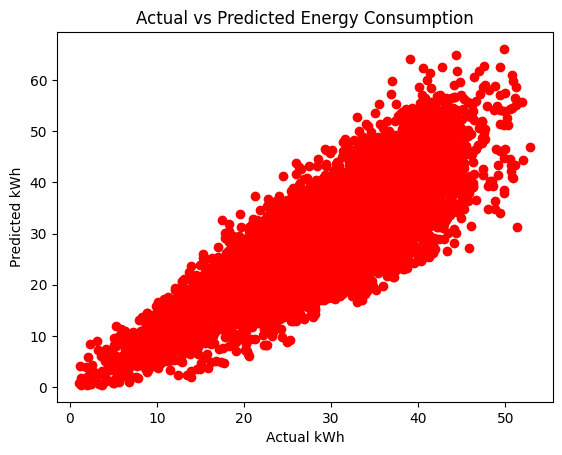

In [18]:
import matplotlib.pyplot as plt

plt.scatter(predict_kwh, observed_kwh, color = 'red')

plt.xlabel("Actual kWh")
plt.ylabel("Predicted kWh")
plt.title("Actual vs Predicted Energy Consumption")

plt.show()

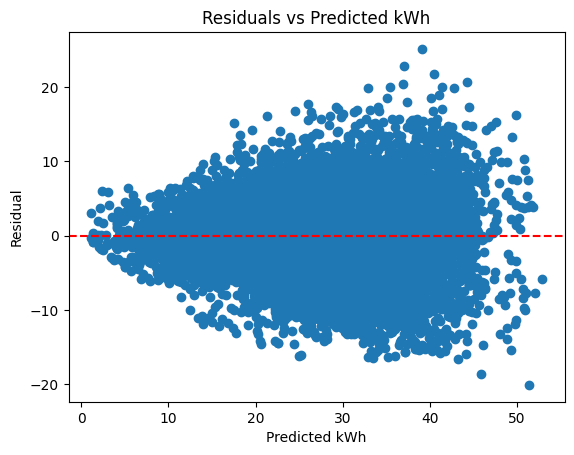

In [19]:
residuals = observed_kwh - predict_kwh

plt.scatter(predict_kwh, residuals)

plt.axhline(y=0, linestyle="--", color = 'red')
 
plt.xlabel("Predicted kWh")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted kWh")

plt.show()

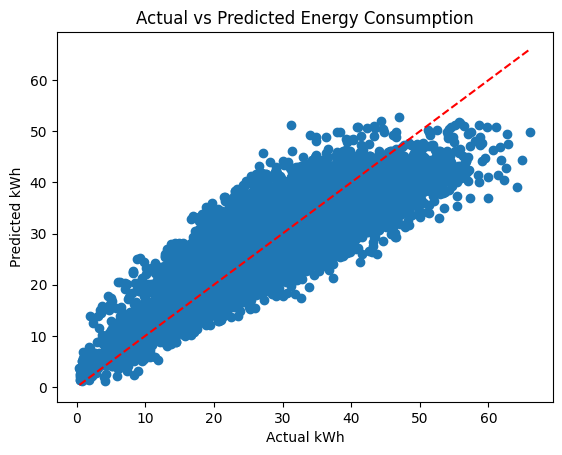

In [20]:
plt.scatter(observed_kwh, predict_kwh)

plt.plot(
    [observed_kwh.min(), observed_kwh.max()],
    [observed_kwh.min(), observed_kwh.max()],
    linestyle="--",
    color = 'red'
)

plt.xlabel("Actual kWh")
plt.ylabel("Predicted kWh")
plt.title("Actual vs Predicted Energy Consumption") 

plt.show()

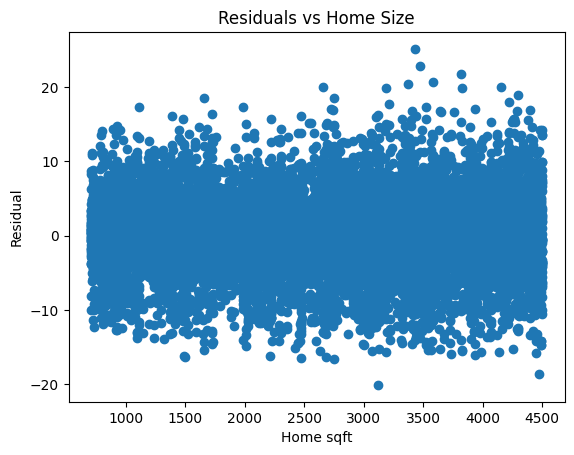

In [21]:
plt.scatter(df.loc[x_test.index, "home_sqft"], residuals)

plt.xlabel("Home sqft")
plt.ylabel("Residual")
plt.title("Residuals vs Home Size")

plt.show()

In [22]:
# feature engineerning
# creating new columns and eliminating one which cause errors  like  temp range - > tempmax - tempmin

# df["month"] = df["date"].dt.month
# df["day_of_week"] = df["date"].dt.dayofweek
# df = df.drop("date", axis=1)
# df["temp_range"] = df["temp_max_c"] - df["temp_min_c"]
# df["temp_avg_squared"] = df["temp_avg_c"] ** 2    a linear reg assumes linear line   square temp can reach to curve  ->a*temp + b*temp^2
# df["sqft_per_resident"] = (df["home_sqft"] / df["num_residents"])
# df["residents_per_1000sqft"] = (df["num_residents"] / df["home_sqft"] * 1000)
# df["hvac_old"] = (df["hvac_age_years"] > 10).astype(int)

# df["sqft_ev"] = (
#     df["home_sqft"] * df["has_ev"]
# )

# df["sqft_pool"] = (
#     df["home_sqft"] * df["has_pool"]
# )

# df["temp_humidity"] = (
#     df["temp_avg_c"] * df["humidity_pct"]
# )

# df["month"] = df["date"].dt.month
# df["day_of_week"] = df["date"].dt.dayofweek